### **INSTALACIÓN DE LIBRERÍAS**

In [1]:
!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn

### **IMPORTACIÓN DE MÓDULOS Y CONFIGURACIÓN DE VISUALIZACIÓN**

In [4]:
import pandas as pd
import numpy as np
import time
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### **CARGA DEL DATASET HAI**

In [11]:
# Definir las rutas locales de Colab (cámbialas si las pones en otra carpeta)
path_train = ['/content/hai-train1.csv', '/content/hai-train2.csv',
              '/content/hai-train3.csv', '/content/hai-train4.csv']

path_test = ['/content/hai-test1.csv', '/content/hai-test2.csv']
path_labels = ['/content/label-test1.csv', '/content/label-test2.csv']

try:
    # 1. Carga y procesa TRAIN (Tráfico Normal -> Etiqueta 0)
    print("Cargando archivos de Entrenamiento (Normal)...")
    df_train_list = []
    for f in path_train:
        temp_df = pd.read_csv(f)
        temp_df['Attack'] = 0
        df_train_list.append(temp_df)

    df_train = pd.concat(df_train_list, ignore_index=True)

    # 2. Carga y procesa TEST con sus ETIQUETAS (Contiene Ataques)
    print("Cargando archivos de Prueba y sus etiquetas...")

    # Test 1
    df_test1 = pd.read_csv(path_test[0])
    label1 = pd.read_csv(path_labels[0])
    col_ataque = 'attack' if 'attack' in label1.columns else label1.columns[-1]
    df_test1['Attack'] = label1[col_ataque]

    # Test 2
    df_test2 = pd.read_csv(path_test[1])
    label2 = pd.read_csv(path_labels[1])
    df_test2['Attack'] = label2[col_ataque]

    df_test = pd.concat([df_test1, df_test2], ignore_index=True)

    # 3. UNIR TODO EN UN SOLO DATASET MAESTRO
    df = pd.concat([df_train, df_test], ignore_index=True)
    label_col = 'Attack'

    print("\nFusión completada")
    print(f"Dimensiones del dataset maestro: {df.shape}")
    print("\nDistribución Real de las Clases:")
    print(df['Attack'].value_counts())

except Exception as e:
    print(f"\nERROR AL CARGAR LOS ARCHIVOS: {e}")
    print("Verifica que los archivos estén subidos al entorno de Colab y las rutas sean correctas.")

Cargando archivos de Entrenamiento (Normal)...
Cargando archivos de Prueba y sus etiquetas...

Fusión completada
Dimensiones del dataset maestro: (1180800, 88)

Distribución Real de las Clases:
Attack
0    1169416
1      11384
Name: count, dtype: int64


### **DISTRIBUCIÓN DE CLASES**

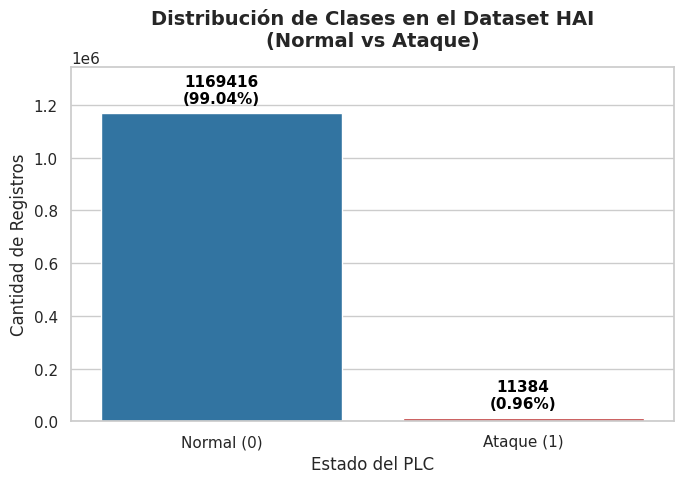

In [12]:
# Configura el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Crea el gráfico de barras
ax = sns.countplot(x='Attack', data=df, palette=['#1f77b4', '#d62728'])

# Personalizar títulos y etiquetas
plt.title('Distribución de Clases en el Dataset HAI\n(Normal vs Ataque)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estado del PLC', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Ataque (1)'])

# Agregamos los números y porcentajes encima de cada barra
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        porcentaje = f'{100 * height / total:.2f}%'
        ax.annotate(f'{int(height)}\n({porcentaje})',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.ylim(0, df['Attack'].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

### **PREPROCESAMIENTO Y DIVISIÓN ESTRATIFICADA**

In [13]:
# 1. Eliminación de columnas de tiempo o texto puro (XGBoost solo lee números)
cols_to_drop = [col for col in df.columns if 'time' in col.lower() or df[col].dtype == 'object']
if cols_to_drop:
    print(f"Eliminando columnas no numéricas/temporales: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

# 2. Separación de variables (X) de la etiqueta (y)
X = df.drop(columns=[label_col])
y = df[label_col].astype(int)

# 3. Manejo de Nulos (Rellenar con la mediana para no perder filas)
if X.isnull().sum().sum() > 0:
    print("Rellenando valores nulos con la mediana...")
    X = X.fillna(X.median())

# 4. División Estratificada
print("Realizando división estratificada 70/30...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 5. Escalamiento de los datos (Z-Score Normalization)
print("Escalando las características (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mantenemos los nombres de las columnas (Tags) para el Feature Importance después
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Preprocesamiento finalizado. Listo para entrenar.")

Eliminando columnas no numéricas/temporales: ['timestamp']
Realizando división estratificada 70/30...
Escalando las características (StandardScaler)...
Preprocesamiento finalizado. Listo para entrenar.


### **ENTRENAMIENTO Y MÉTRICAS**


ENTRENAMIENTO Y EVALUACIÓN: XGBOOST (HIDS para PLC)


Ratio de penalización calculado: 102.72
Ratio de penalización ajustado (XGBoost): 25.68
Entrenando el modelo...

----------------------------------------
RESULTADOS DE RENDIMIENTO
----------------------------------------

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    350825
      Ataque       0.60      0.95      0.74      3415

    accuracy                           0.99    354240
   macro avg       0.80      0.97      0.87    354240
weighted avg       1.00      0.99      0.99    354240

AUC-ROC Score: 0.9989

Tiempo de Entrenamiento: 51.9333 segundos
Tiempo de Inferencia (Total): 1.3107 segundos
Velocidad de Detección: 0.000004 segundos por registro




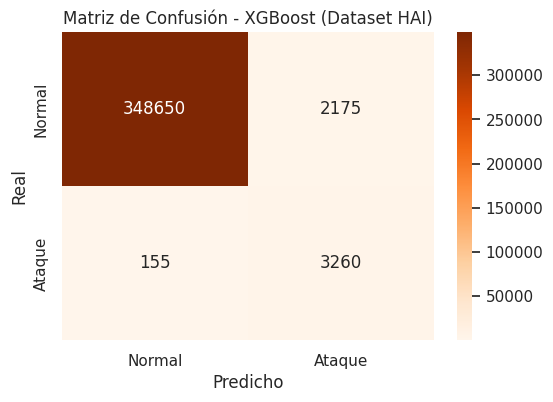



Tasa de Falsos Positivos (FPR): 0.0062


Tasa de Falsos Negativos (FNR): 0.0454




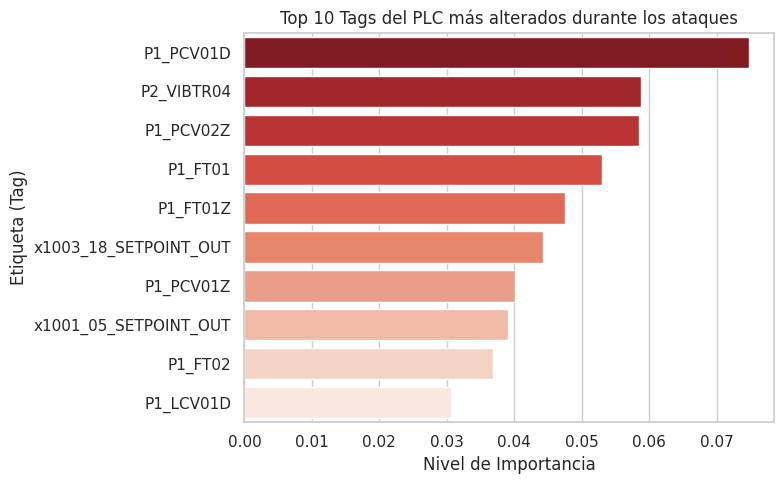

In [29]:
print("\n" + "="*60)
print("ENTRENAMIENTO Y EVALUACIÓN: XGBOOST (HIDS para PLC)")
print("="*60)
print("\n")

# 1. Cálculo del ratio de desbalanceo exacto para pasárselo a XGBoost
ratio_desbalanceo = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Ratio de penalización calculado: {ratio_desbalanceo:.2f}")
factor_atenuacion = 0.25
ratio_ajustado = ratio_desbalanceo * factor_atenuacion
print(f"Ratio de penalización ajustado (XGBoost): {ratio_ajustado:.2f}")

# 2. Configuración del Modelo XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio_ajustado,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 3. Entrenar midiendo el tiempo exacto
start_train = time.time()
print("Entrenando el modelo...")
xgb_model.fit(X_train_scaled, y_train)
end_train = time.time()

# 4. Inferir midiendo el tiempo exacto
start_infer = time.time()
y_pred_xgb = xgb_model.predict(X_test_scaled)
end_infer = time.time()

y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 5. Reportes Numéricos
print("\n" + "-"*40)
print("RESULTADOS DE RENDIMIENTO")
print("-"*40)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Ataque']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

tiempo_inferencia_total = end_infer - start_infer
tiempo_por_registro = tiempo_inferencia_total / len(X_test_scaled)
print(f"\nTiempo de Entrenamiento: {end_train - start_train:.4f} segundos")
print(f"Tiempo de Inferencia (Total): {tiempo_inferencia_total:.4f} segundos")
print(f"Velocidad de Detección: {tiempo_por_registro:.6f} segundos por registro")
print("\n")

# 6. GRÁFICAS (Matriz de Confusión)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Ataque'], yticklabels=['Normal', 'Ataque'])
plt.title('Matriz de Confusión - XGBoost (Dataset HAI)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()
print("\n")

# FIABLILIDAD DE DETECCIÓN

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
fpr = fp / (fp + tn)
print(f"Tasa de Falsos Positivos (FPR): {fpr:.4f}")
print("\n")

fnr = fn / (fn + tp)
print(f"Tasa de Falsos Negativos (FNR): {fnr:.4f}")
print("\n")

# 7. GRÁFICAS (Importancia de Variables)
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

top_n = 10
top_features = [X.columns[i] for i in indices_xgb[:top_n]]
top_importances = importances_xgb[indices_xgb][:top_n]

plt.figure(figsize=(8,5))
sns.barplot(x=top_importances, y=top_features, palette="Reds_r")
plt.title('Top 10 Tags del PLC más alterados durante los ataques')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Etiqueta (Tag)')
plt.tight_layout()
plt.show()

### **GRAFICO AUC/ROC**


8. GRÁFICA: CURVA ROC Y AUC (XGBoost)


AUC ROC Calculado para la gráfica: 0.9989




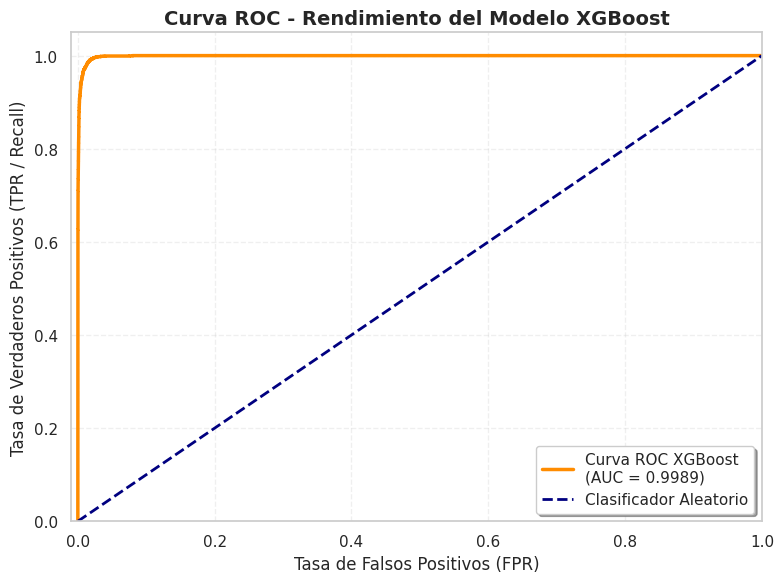

In [32]:
print("\n" + "="*60)
print("8. GRÁFICA: CURVA ROC Y AUC (XGBoost)")
print("="*60)
print("\n")

# 1. Identificar dinámicamente la columna exacta que corresponde a la clase '1' (Ataque)
indice_ataque = list(xgb_model.classes_).index(1)

# 2. Extraer las probabilidades correctas asegurando que sean de los ataques
y_proba_roc = xgb_model.predict_proba(X_test_scaled)[:, indice_ataque]

# 3. Calcular los puntos para la Curva ROC
fpr_roc, tpr_roc, umbrales_roc = roc_curve(y_test, y_proba_roc)
roc_auc_valor = auc(fpr_roc, tpr_roc)

print(f"AUC ROC Calculado para la gráfica: {roc_auc_valor:.4f}")
print("\n")

# 4. Graficar la Curva ROC con formato académico
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2.5,
         label=f'Curva ROC XGBoost\n(AUC = {roc_auc_valor:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')

# Formateo del gráfico
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
plt.title('Curva ROC - Rendimiento del Modelo XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print("\n")